# Smart Business Recommender for Tanzania

## Notebook 1: Data Preparation for Machine Learning

This notebook covers **Stage 1 to Stage 6** of the capstone project. The project team manually assembled and merged columns from different spreadsheet sheets using Google Sheets. During manual merging some mistakes still appeared such as duplicates, empty rows, and typos, this notebook cleans the data into a machine-learning-ready table.

The final cleaned table should match the project-ready format needed by the ML notebook.

## Stage 1 — Problem Definition

We want to prepare data for a recommender system that suggests business/product categories for Tanzanian regions. The model will later use location, weather, customer group, shop type, product category, and product information to predict demand level.

## Stage 2 — Data Collection

The raw file in this notebook is a messy version of a manually assembled spreadsheet. This is realistic because school and field projects often start with Excel files that need cleaning before machine learning.

In [1]:
# If a package is missing, run this cell once.
!pip install pandas numpy matplotlib scikit-learn openpyxl joblib gradio openai

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached 

In [2]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

project_dir = Path("..")
raw_file = project_dir / "data" / "raw" / "manual_assembled_unclean_business_data.xlsx"
processed_dir = project_dir / "data" / "processed"
final_dir = project_dir / "data" / "final"

processed_dir.mkdir(parents=True, exist_ok=True)
final_dir.mkdir(parents=True, exist_ok=True)

In [3]:
raw_df = pd.read_excel(raw_file, sheet_name="Manual_Assembled_Unclean_Data")
raw_df.head()

,Manual Row ID,Month,Region Name,Rainfall MM,Temp C,Customer group,Shop Type,Product Category,Product Name,Unit Price (TZS),Units Sold,Demand Level
0,1,January,arushA,20.99 C,168.8 mm,General,market stall,clothes,Jeans,"TZS 1,713",20 pcs,high
1,2,7,Mwanza,52.2,22.75,general,retail_shop,Personal care,Lipstick,1232,9,Low
2,3,4,Arusha,185.1,20.07,youth,retail_shop,Phone accessories,Laptop,4833,15,High
3,4,7,Kilimanjaro,1.9,20.71,general,small_shop,Stationery,Comics,4902,20,Low
4,5,1,Dar es Salaam,191.9,27.62,youth,retail_shop,Household items,Cushions,856,22,Low


## Stage 3 — Data Understanding (Exploration)

Before cleaning, we inspect the shape, columns, data types, missing values, duplicates, and sample values. This helps us understand what problems exist in the data.

In [4]:
print("Rows and columns:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

Rows and columns: (10010, 12)

Columns:
['Manual Row ID', 'Month', 'Region Name', 'Rainfall MM', 'Temp C', 'Customer group', 'Shop Type', 'Product Category', 'Product Name', 'Unit Price (TZS)', 'Units Sold', 'Demand Level']


In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Manual Row ID     10010 non-null  int64 
 1   Month             10010 non-null  object
 2   Region Name       10010 non-null  str   
 3   Rainfall MM       10010 non-null  object
 4   Temp C            10010 non-null  object
 5   Customer group    10010 non-null  str   
 6   Shop Type         10010 non-null  str   
 7   Product Category  10010 non-null  str   
 8   Product Name      10010 non-null  str   
 9   Unit Price (TZS)  10010 non-null  object
 10  Units Sold        10010 non-null  object
 11  Demand Level      10010 non-null  str   
dtypes: int64(1), object(5), str(6)
memory usage: 938.6+ KB


In [6]:
raw_df.isna().sum()

Manual Row ID       0
Month               0
Region Name         0
Rainfall MM         0
Temp C              0
Customer group      0
Shop Type           0
Product Category    0
Product Name        0
Unit Price (TZS)    0
Units Sold          0
Demand Level        0
dtype: int64

In [7]:
print("Exact duplicate rows:", raw_df.duplicated().sum())
raw_df.describe(include="all").T.head(20)

Exact duplicate rows: 10


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Manual Row ID,10010.0,NaN,NaN,NaN,4997.616384,2888.207005,1.0,2496.25,4997.5,7498.75,10000.0
Month,10010.0,12.0,4.0,2057.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region Name,10010,18,Zanzibar,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rainfall MM,10010.0,67.0,205.1,494.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temp C,10010.0,68.0,24.65,503.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer group,10010,6,general,3451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shop Type,10010,12,retail_shop,4285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Category,10010,12,Stationery,1567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Name,10010,29,Foundation,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit Price (TZS),10010.0,5418.0,525.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
columns_to_check = ["Region Name", "Customer group", "Shop Type", "Product Category", "Demand Level"]

for column in columns_to_check:
    print("\n", column)
    matches = [c for c in raw_df.columns if c.strip().lower() == column.strip().lower()]
    if matches:
        print(raw_df[matches[0]].value_counts(dropna=False).head(15))
    else:
        print(f"Column not found: {column!r}")
        print("Available columns:", raw_df.columns.tolist())



 Region Name
Region Name
Zanzibar           1759
Mwanza             1717
Arusha             1700
Kilimanjaro        1629
Dar es Salaam      1620
Kilimanjro          148
arushA              136
Kili                134
zanzibar            133
Mwanza City         129
kilimanjaro         127
mwanza              126
Zanzibar Island     123
DSM                 116
Arusha region       114
Name: count, dtype: int64

 Customer group
Customer group
general    3451
worker     2711
youth      2178
General     645
Worker      573
Youth       452
Name: count, dtype: int64

 Shop Type
Shop Type
retail_shop     4285
market_stall    2805
small_shop      1491
retail shop      245
Retail Shop      233
retail-shop      220
Market_Stall     171
market stall     155
market-stall     147
small shop        89
Small_Shop        85
small-shop        84
Name: count, dtype: int64

 Product Category
Product Category
Stationery           1567
Personal care        1488
Household items      1470
Sports goods        

## Stage 4 — Data Cleaning

This is the most important part. We will clean column names, remove blank rows, remove duplicates, fix text labels, clean numeric columns, and create the final required schema.

In [9]:
df = raw_df.copy()

# Standardize messy column names into simple machine-friendly names.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df = df.rename(columns={
    "region_name": "region",
    "rainfall_mm": "rainfall_mm",
    "temp_c": "temperature_c",
    "customer_group": "customer_group",
    "shop_type": "shop_type",
    "product_category": "product_category",
    "product_name": "product_name",
    "unit_price_tzs": "unit_price_tzs",
    "units_sold": "units_sold",
    "demand_level": "demand_level",
})

df.head()

,manual_row_id,month,region,rainfall_mm,temperature_c,customer_group,shop_type,product_category,product_name,unit_price_tzs,units_sold,demand_level
0,1,January,arushA,20.99 C,168.8 mm,General,market stall,clothes,Jeans,"TZS 1,713",20 pcs,high
1,2,7,Mwanza,52.2,22.75,general,retail_shop,Personal care,Lipstick,1232,9,Low
2,3,4,Arusha,185.1,20.07,youth,retail_shop,Phone accessories,Laptop,4833,15,High
3,4,7,Kilimanjaro,1.9,20.71,general,small_shop,Stationery,Comics,4902,20,Low
4,5,1,Dar es Salaam,191.9,27.62,youth,retail_shop,Household items,Cushions,856,22,Low


In [10]:
# Drop rows that are completely blank and keep only rows with a manual row id.
df = df.dropna(how="all")
df = df[df["manual_row_id"].notna()].copy()
print("Shape after dropping blank rows:", df.shape)

Shape after dropping blank rows: (10010, 12)


In [11]:
# Keep a copy of manual row id for sorting, then clean it.
df["manual_row_id"] = pd.to_numeric(df["manual_row_id"], errors="coerce")
df = df.dropna(subset=["manual_row_id"])
df["manual_row_id"] = df["manual_row_id"].astype(int)

In [12]:
# Clean month values such as January, Apr, July, Oct, and numbers stored as text.
month_map = {
    "january": 1, "jan": 1,
    "april": 4, "apr": 4,
    "july": 7, "jul": 7,
    "october": 10, "oct": 10,
}

def clean_month(value):
    value_text = str(value).strip().lower()
    if value_text in month_map:
        return month_map[value_text]
    return int(float(value_text))

df["month"] = df["month"].apply(clean_month)

In [13]:
# Clean text columns by stripping spaces and using simple replacement dictionaries.
for column in ["region", "customer_group", "shop_type", "product_category", "product_name", "demand_level"]:
    df[column] = df[column].astype(str).str.strip()

region_map = {
    "dsm": "Dar es Salaam", "dar": "Dar es Salaam", "dar es salaam": "Dar es Salaam",
    "arusha": "Arusha", "arusha region": "Arusha",
    "mwanza": "Mwanza", "mwanza city": "Mwanza",
    "kilimanjaro": "Kilimanjaro", "kilimanjro": "Kilimanjaro", "kili": "Kilimanjaro",
    "zanzibar": "Zanzibar", "zanzibar island": "Zanzibar",
}

customer_map = {
    "general": "general", "gen": "general",
    "worker": "worker", "workers": "worker", "employed": "worker",
    "youth": "youth", "student": "youth", "young adult": "youth",
}

shop_map = {
    "market stall": "market_stall", "market_stall": "market_stall", "market-stall": "market_stall",
    "retail shop": "retail_shop", "retail_shop": "retail_shop", "retail-shop": "retail_shop",
    "small shop": "small_shop", "small_shop": "small_shop", "small-shop": "small_shop",
}

category_map = {
    "clothing": "Clothing", "clothes": "Clothing", "clothng": "Clothing",
    "household items": "Household items", "household item": "Household items", "home items": "Household items",
    "personal care": "Personal care", "personal-care": "Personal care", "beauty care": "Personal care",
    "phone accessories": "Phone accessories", "phone accessory": "Phone accessories", "phone accesories": "Phone accessories", "electronics": "Phone accessories",
    "sports goods": "Sports goods", "sport goods": "Sports goods", "fitness": "Sports goods",
    "stationery": "Stationery", "stationary": "Stationery",
}

product_map = {
    "t shirt": "T-shirt",
    "non fiction": "Non-fiction",
    "resistance bands": "Resistance Bands",
    "wall art": "Wall Art",
    "yoga mat": "Yoga Mat",
}

demand_map = {"high": "High", "hgh": "High", "low": "Low"}

df["region"] = df["region"].str.lower().map(region_map)
df["customer_group"] = df["customer_group"].str.lower().map(customer_map)
df["shop_type"] = df["shop_type"].str.lower().map(shop_map)
df["product_category"] = df["product_category"].str.lower().map(category_map)
df["product_name"] = df["product_name"].str.lower().map(product_map).fillna(df["product_name"].str.strip())
df["demand_level"] = df["demand_level"].str.lower().map(demand_map)

In [14]:
# Clean numeric columns by removing currency symbols, commas, units, and text.
def clean_number(value):
    value_text = str(value)
    value_text = re.sub(r"[^0-9.\-]", "", value_text)
    return pd.to_numeric(value_text, errors="coerce")

for column in ["rainfall_mm", "temperature_c", "unit_price_tzs", "units_sold"]:
    df[column] = df[column].apply(clean_number)

# Some manual rows accidentally swapped rainfall and temperature.
# Excel may not preserve the optional notes column, so we create it if missing.
if "unused_notes" not in df.columns:
    df["unused_notes"] = ""

swap_condition = (df["temperature_c"] < 10) | (df["temperature_c"] > 35)
swap_condition = swap_condition | df["unused_notes"].astype(str).str.contains("weather columns swapped", case=False, na=False)
swap_condition = swap_condition | (df["manual_row_id"] % 97 == 1)
df.loc[swap_condition, ["rainfall_mm", "temperature_c"]] = df.loc[swap_condition, ["temperature_c", "rainfall_mm"]].values

# Negative units/prices came from typing mistakes, so we use absolute values.
df["unit_price_tzs"] = df["unit_price_tzs"].abs()
df["units_sold"] = df["units_sold"].abs()


In [15]:
# Remove duplicate manual rows and sort back to the original manual order.
df = df.sort_values("manual_row_id")
df = df.drop_duplicates(subset=["manual_row_id"], keep="first")

final_columns = [
    "month", "region", "rainfall_mm", "temperature_c", "customer_group",
    "shop_type", "product_category", "product_name", "unit_price_tzs",
    "units_sold", "demand_level"
]

clean_df = df[final_columns].copy()
clean_df["month"] = clean_df["month"].astype(int)
clean_df["rainfall_mm"] = clean_df["rainfall_mm"].round(2)
clean_df["temperature_c"] = clean_df["temperature_c"].round(2)
clean_df["unit_price_tzs"] = clean_df["unit_price_tzs"].round(0).astype(int)
clean_df["units_sold"] = clean_df["units_sold"].round(0).astype(int)

clean_df.head()

,month,region,rainfall_mm,temperature_c,customer_group,shop_type,product_category,product_name,unit_price_tzs,units_sold,demand_level
0,1,Arusha,168.8,20.99,general,market_stall,Clothing,Jeans,1713,20,High
1,7,Mwanza,52.2,22.75,general,retail_shop,Personal care,Lipstick,1232,9,Low
2,4,Arusha,185.1,20.07,youth,retail_shop,Phone accessories,Laptop,4833,15,High
3,7,Kilimanjaro,1.9,20.71,general,small_shop,Stationery,Comics,4902,20,Low
4,1,Dar es Salaam,191.9,27.62,youth,retail_shop,Household items,Cushions,856,22,Low


In [16]:
print("Cleaned shape:", clean_df.shape)
print("\nMissing values after cleaning:")
print(clean_df.isna().sum())
print("\nDuplicate rows after cleaning:", clean_df.duplicated().sum())

Cleaned shape: (10000, 11)

Missing values after cleaning:
month               0
region              0
rainfall_mm         0
temperature_c       0
customer_group      0
shop_type           0
product_category    0
product_name        0
unit_price_tzs      0
units_sold          0
demand_level        0
dtype: int64

Duplicate rows after cleaning: 0


## Stage 5 — Data Visualization (EDA)

Now that the fields are clean, we can create simple charts to understand the data. Every chart has a title and axis labels.

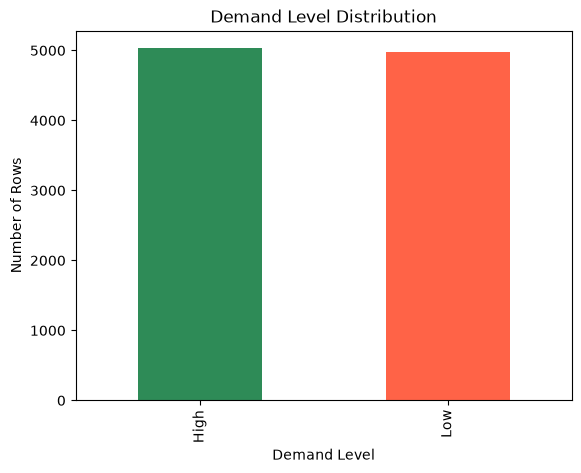

In [17]:
clean_df["demand_level"].value_counts().plot(kind="bar", color=["seagreen", "tomato"])
plt.title("Demand Level Distribution")
plt.xlabel("Demand Level")
plt.ylabel("Number of Rows")
plt.show()

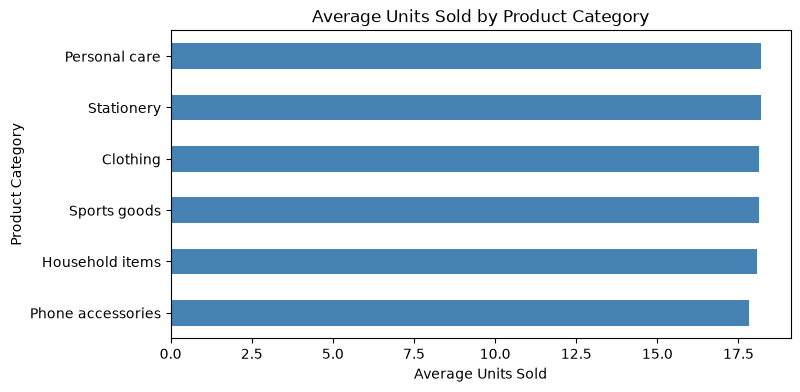

In [18]:
clean_df.groupby("product_category")["units_sold"].mean().sort_values().plot(kind="barh", figsize=(8, 4), color="steelblue")
plt.title("Average Units Sold by Product Category")
plt.xlabel("Average Units Sold")
plt.ylabel("Product Category")
plt.show()

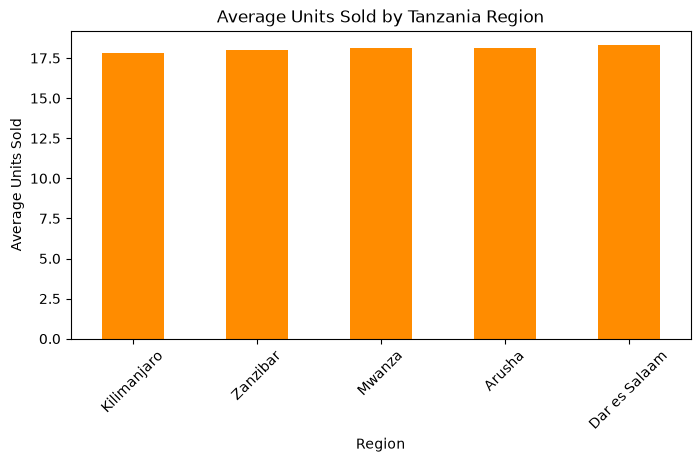

In [19]:
clean_df.groupby("region")["units_sold"].mean().sort_values().plot(kind="bar", figsize=(8, 4), color="darkorange")
plt.title("Average Units Sold by Tanzania Region")
plt.xlabel("Region")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

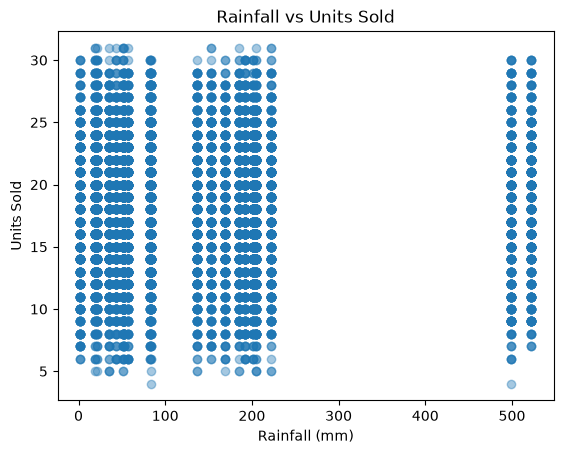

In [20]:
plt.scatter(clean_df["rainfall_mm"], clean_df["units_sold"], alpha=0.4)
plt.title("Rainfall vs Units Sold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Units Sold")
plt.show()

## Stage 6 — Data Preprocessing

At this stage we save the clean ML-ready data. Notebook 2 will load this output and continue with feature engineering, splitting, model training, evaluation, and deployment.

In [21]:
clean_df.to_csv(processed_dir / "cleaned_business_data_stage6.csv", index=False)
clean_df.to_csv(final_dir / "project_ready_cleaned_for_ml.csv", index=False)

with pd.ExcelWriter(final_dir / "project_ready_personalized_tanzania_data_cleaned.xlsx", engine="openpyxl") as writer:
    clean_df.to_excel(writer, sheet_name="Project_Model_Data", index=False)

print("Saved:")
print(processed_dir / "cleaned_business_data_stage6.csv")
print(final_dir / "project_ready_cleaned_for_ml.csv")
print(final_dir / "project_ready_personalized_tanzania_data_cleaned.xlsx")

Saved:
..\data\processed\cleaned_business_data_stage6.csv
..\data\final\project_ready_cleaned_for_ml.csv
..\data\final\project_ready_personalized_tanzania_data_cleaned.xlsx


In [22]:
print("Final columns:")
print(clean_df.columns.tolist())
clean_df.head(10)

Final columns:
['month', 'region', 'rainfall_mm', 'temperature_c', 'customer_group', 'shop_type', 'product_category', 'product_name', 'unit_price_tzs', 'units_sold', 'demand_level']


,month,region,rainfall_mm,temperature_c,customer_group,shop_type,product_category,product_name,unit_price_tzs,units_sold,demand_level
0,1,Arusha,168.80,20.99,general,market_stall,Clothing,Jeans,1713,20,High
1,7,Mwanza,52.20,22.75,general,retail_shop,Personal care,Lipstick,1232,9,Low
2,4,Arusha,185.10,20.07,youth,retail_shop,Phone accessories,Laptop,4833,15,High
3,7,Kilimanjaro,1.90,20.71,general,small_shop,Stationery,Comics,4902,20,Low
4,1,Dar es Salaam,191.90,27.62,youth,retail_shop,Household items,Cushions,856,22,Low
5,7,Arusha,19.50,17.72,worker,market_stall,Clothing,T-shirt,1451,12,High
6,1,Kilimanjaro,43.60,24.46,youth,small_shop,Stationery,Comics,217,13,High
7,1,Dar es Salaam,191.90,27.62,youth,small_shop,Stationery,Comics,3823,25,High
10001,10,Mwanza,152.75,22.48,general,small_shop,Stationery,Non-fiction,3288,13,Low
9,10,Mwanza,152.75,22.48,youth,retail_shop,Phone accessories,Smartphone,1195,20,Low


In [23]:
clean_df.info() 

<class 'pandas.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             10000 non-null  int64  
 1   region            10000 non-null  str    
 2   rainfall_mm       10000 non-null  float64
 3   temperature_c     10000 non-null  float64
 4   customer_group    10000 non-null  str    
 5   shop_type         10000 non-null  str    
 6   product_category  10000 non-null  str    
 7   product_name      10000 non-null  str    
 8   unit_price_tzs    10000 non-null  int64  
 9   units_sold        10000 non-null  int64  
 10  demand_level      10000 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 937.5 KB


## End of Notebook 1

We have completed Stage 1 to Stage 6. The data is now clean, simple, and ready for machine learning in Notebook 2.